# Tutorial

Experimental Settings:

In [1]:
from PriceFM import *

pre_path = train_status('local') # 'local' or 'cloud', cloud for GoogleColab
model_path = pre_path+"Model/PriceFM.keras" # location to save the model
european_energy_df = pre_path+'Data/EU_Spatiotemporal_Energy_Data.csv' # location of dataset
european_energy_df = pd.read_csv(european_energy_df)

# master lists of input features [not change]
input_features = ['day_ahead_Solar', 'day_ahead_Wind Onshore', 'day_ahead_Wind Offshore', 'Forecasted Load']

# master lists of region codes [not change]
all_regions = ['AT',    'BE',    'BG',   'CZ',    'DE_LU',   'DK_1',  'DK_2',                 
               'EE',    'ES',    'FI',   'FR',    'GR',      'HR',    'HU',                  
               'IT_1',  'IT_2',  'IT_3', 'IT_4',  'IT_5',    'IT_6',  'IT_7', 
               'LT',    'LV',    'NL',   'NO_1',  'NO_2',    'NO_3',  'NO_4',   'NO_5', 
               'PL',    'PT',    'RO',   'SE_1',  'SE_2',    'SE_3',  'SE_4',   'SI',   'SK']

# quantiles for prediction, e.g., 10%, 50%, and 90% quantiles [can change]
QUANTILES = [10, 50, 90] 

# input regions of the model [can change]
input_regions =  all_regions 

# output regions for prediction;
# here can be a list of lists, e.g., [['AT'], ['AT', 'BE']] for individual region or combinations
# if specified as [['AT'], ['AT', 'BE']], then we train 2 models, one to predict AT, and another to predict AT and BE. [can change]
TARGET_REGIONS = [all_regions] 

# optimal model hyperparameters [can change]
num_layer, hidden_dim, epoch, batch_size, show_progress_bar = (3, 24, 20, 8, True)

# data splits for training, validation, and testing [can change]
data_splits = [('2022-01-01', '2024-01-01', '2024-07-01', '2025-01-01')]

# time windows for input and output [can change]
look_back_windows = [-24] # the last 24 hours of data as input. [-24, -23, ...-1]
prediction_horizons = [23] # the next 24 hours to predict / look-forward window size for load, solar, and wind. [0, 1, ...23]

# seeds for randomness [can change]
seeds = [42] 

# run the optimal model or ablation study [can change]
select_modes = ['optimal']

Python version: 3.10.15 | packaged by Anaconda, Inc. | (main, Oct  3 2024, 07:22:19) [MSC v.1929 64 bit (AMD64)]
TensorFlow version: 2.16.2
NumPy version: 1.25.2
Pandas version: 2.2.2
Scikit-learn version: 1.5.2


# 0. Regional File Formation

Make sure to run the following line if you first time execute the code:

it generates data file, where regional data can be retrieved using region code.

The file is saved under 'Data' folder

In [ ]:
generate_region_data_pickles(data_splits, look_back_windows, prediction_horizons, all_regions, european_energy_df, input_features, pre_path)

# 1. MIMO / MISO / SISO settings

if you prefer multi-input multi-output setup:

In [9]:
input_regions =  all_regions  # keep all regions as input
TARGET_REGIONS = [all_regions]  # predict all regions as output

In [ ]:
# [execution code] this block remains the same
for data_split in data_splits:
    train_start, val_start, test_start, _ = data_split
    for look_back_window in look_back_windows:
        for prediction_horizon in prediction_horizons:
            for output_regions in TARGET_REGIONS:
                for seed in seeds:
                    for select_mode in select_modes:
                        print(f"Running configuration: {train_start}, {val_start}, {test_start}, "
                                f"look_back_window={look_back_window}, prediction_horizon={prediction_horizon}, "
                                f"output_regions={output_regions}, seed={seed}, select_mode={select_mode}")
                        
                        region_data = load_region_data(pre_path, train_start, val_start, test_start, look_back_window, prediction_horizon)
                        train_inputs, val_inputs, y_train_dict, y_val_dict = build_data(region_data, input_regions, output_regions, QUANTILES)
                        model = build_model_mode(select_mode, region_data, input_regions, output_regions, num_layer, hidden_dim, QUANTILES)
                        best_model, history, model_params = run_model(model, QUANTILES, output_regions, train_inputs, val_inputs, y_train_dict, y_val_dict, epoch, batch_size, model_path, show_progress_bar)
                        results = evaluate_model_unseen(region_data, input_regions, output_regions, model_path, QUANTILES)
                        hyper_setup = (train_start, val_start, test_start, look_back_window, prediction_horizon, model_params, seed, select_mode)
                        save_as_csv(results, hyper_setup, history, QUANTILES, pre_path)

if you prefer multi-input single-output setup:

In [13]:
input_regions =  all_regions  # keep all regions as input
TARGET_REGIONS = [['AT']]  # predict e.g. Austria (AT)

In [ ]:
# [execution code] this block remains the same
for data_split in data_splits:
    train_start, val_start, test_start, _ = data_split
    for look_back_window in look_back_windows:
        for prediction_horizon in prediction_horizons:
            for output_regions in TARGET_REGIONS:
                for seed in seeds:
                    for select_mode in select_modes:
                        print(f"Running configuration: {train_start}, {val_start}, {test_start}, "
                                f"look_back_window={look_back_window}, prediction_horizon={prediction_horizon}, "
                                f"output_regions={output_regions}, seed={seed}, select_mode={select_mode}")
                        
                        region_data = load_region_data(pre_path, train_start, val_start, test_start, look_back_window, prediction_horizon)
                        train_inputs, val_inputs, y_train_dict, y_val_dict = build_data(region_data, input_regions, output_regions, QUANTILES)
                        model = build_model_mode(select_mode, region_data, input_regions, output_regions, num_layer, hidden_dim, QUANTILES)
                        best_model, history, model_params = run_model(model, QUANTILES, output_regions, train_inputs, val_inputs, y_train_dict, y_val_dict, epoch, batch_size, model_path, show_progress_bar)
                        results = evaluate_model_unseen(region_data, input_regions, output_regions, model_path, QUANTILES)
                        hyper_setup = (train_start, val_start, test_start, look_back_window, prediction_horizon, model_params, seed, select_mode)
                        save_as_csv(results, hyper_setup, history, QUANTILES, pre_path)

if you prefer single-input single-output setup:

In [10]:
input_regions =  ['AT']  # keep one region as input e.g. Austria (AT)
TARGET_REGIONS = [['AT']]  # predict e.g. Austria (AT)

In [ ]:
# [execution code] this block remains the same
for data_split in data_splits:
    train_start, val_start, test_start, _ = data_split
    for look_back_window in look_back_windows:
        for prediction_horizon in prediction_horizons:
            for output_regions in TARGET_REGIONS:
                for seed in seeds:
                    for select_mode in select_modes:
                        print(f"Running configuration: {train_start}, {val_start}, {test_start}, "
                                f"look_back_window={look_back_window}, prediction_horizon={prediction_horizon}, "
                                f"output_regions={output_regions}, seed={seed}, select_mode={select_mode}")
                        
                        region_data = load_region_data(pre_path, train_start, val_start, test_start, look_back_window, prediction_horizon)
                        train_inputs, val_inputs, y_train_dict, y_val_dict = build_data(region_data, input_regions, output_regions, QUANTILES)
                        model = build_model_mode(select_mode, region_data, input_regions, output_regions, num_layer, hidden_dim, QUANTILES)
                        best_model, history, model_params = run_model(model, QUANTILES, output_regions, train_inputs, val_inputs, y_train_dict, y_val_dict, epoch, batch_size, model_path, show_progress_bar)
                        results = evaluate_model_unseen(region_data, input_regions, output_regions, model_path, QUANTILES)
                        hyper_setup = (train_start, val_start, test_start, look_back_window, prediction_horizon, model_params, seed, select_mode)
                        save_as_csv(results, hyper_setup, history, QUANTILES, pre_path)

# 2. Curvature value optimization and settings change

Search the function "get_decay_factor_for_region" from PriceFM.py, where the decay factor is referring to the curvature value that serves as spatial regularizer, and the function looks like:

In [ ]:
def get_decay_factor_for_region(region):
    # optimized curvature mapping per region based on val loss
    DECAY_FACTORS = {
        'AT': 0.8,
        'BE': 0.8,
        'BG': 1.0,
        'CZ': 0.8,
        'DE_LU': 0.0,
        'DK_1': 0.2,
        'DK_2': 0.4,
        'EE': -0.6,
        'ES': 1.0,
        'FI': 1.0,
        'FR': 1.0,
        'GR': 1.0,
        'HR': -0.2,
        'HU': 0.0,
        'IT_1': 1.0,
        'IT_2': 1.0,
        'IT_3': 1.0,
        'IT_4': 1.0,
        'IT_5': 1.0,
        'IT_6': 0.8,
        'IT_7': 1.0,
        'LT': 0.2,
        'LV': 0.4,
        'NL': 0.8,
        'NO_1': 0.8,
        'NO_2': 0.8,
        'NO_3': 0.8,
        'NO_4': 0.6,
        'NO_5': 0.8,
        'PL': 1.0,
        'PT': 1.0,
        'RO': 1.0,
        'SE_1': 0.2,
        'SE_2': 0.8,
        'SE_3': 1.0,
        'SE_4': 1.0,
        'SI': 0.2,
        'SK': 0.0,
    }

    try:
        return DECAY_FACTORS[region]
    except KeyError:
        raise ValueError(f"No decay factor defined for region '{region}'")


The above values are optimized based on validation loss. However, if you believe that the market conditions changed and want to re-optimize, you need to change to MISO setup and find the optimal curvature value based on validation loss. For example:

First find optimal curvature value for Austria (AT):

In [ ]:
input_regions =  all_regions  # keep all regions as input
TARGET_REGIONS = [['AT']]  # optimize for Austria (AT)

and change the value inside the function:

```python
def get_decay_factor_for_region(region):
    # optimized curvature mapping per region based on val loss
    DECAY_FACTORS = {
        'AT': 0, 
        ...

-> and run the [execution code] to observe validation loss: e.g. Val_loss = 0.52

and change the value inside the function:

```python
def get_decay_factor_for_region(region):
    # optimized curvature mapping per region based on val loss
    DECAY_FACTORS = {
        'AT': 0.2, 
        ...

-> and run the [execution code] to observe validation loss: e.g. Val_loss' = 0.51

and change the value inside the function:

```python
def get_decay_factor_for_region(region):
    # optimized curvature mapping per region based on val loss
    DECAY_FACTORS = {
        'AT': 0.4, 
        ...

-> and run the [execution code] to observe validation loss: e.g. Val_loss'' = 0.35

Since Val_loss'' < Val_loss' < Val_loss, the optimal curvature value is thus 0.4

Then, change the target region and repeat above procedure:

In [ ]:
input_regions =  all_regions  # keep all regions as input
TARGET_REGIONS = [['NL']]  # now optimize for Netherlands (NL)

# Visualization of forecasts

As traders observe on forecasts and make trading decisions, we provide visualization

We first train a whatever model:

In [2]:
input_regions =  all_regions  
TARGET_REGIONS = [['DE_LU']] 

In [3]:
# [execution code] this block remains the same
for data_split in data_splits:
    train_start, val_start, test_start, _ = data_split
    for look_back_window in look_back_windows:
        for prediction_horizon in prediction_horizons:
            for output_regions in TARGET_REGIONS:
                for seed in seeds:
                    for select_mode in select_modes:
                        print(f"Running configuration: {train_start}, {val_start}, {test_start}, "
                                f"look_back_window={look_back_window}, prediction_horizon={prediction_horizon}, "
                                f"output_regions={output_regions}, seed={seed}, select_mode={select_mode}")
                        
                        region_data = load_region_data(pre_path, train_start, val_start, test_start, look_back_window, prediction_horizon)
                        train_inputs, val_inputs, y_train_dict, y_val_dict = build_data(region_data, input_regions, output_regions, QUANTILES)
                        model = build_model_mode(select_mode, region_data, input_regions, output_regions, num_layer, hidden_dim, QUANTILES)
                        best_model, history, model_params = run_model(model, QUANTILES, output_regions, train_inputs, val_inputs, y_train_dict, y_val_dict, epoch, batch_size, model_path, show_progress_bar)
                        results = evaluate_model_unseen(region_data, input_regions, output_regions, model_path, QUANTILES)

Running configuration: 2022-01-01, 2024-01-01, 2024-07-01, look_back_window=-24, prediction_horizon=23, output_regions=['DE_LU'], seed=42, select_mode=optimal
🚀 Loaded region_data!

🗺️ Check if adj matrix symmetric: True
✅ Target: DE_LU, curvature=0.0, max_distance=7
 - DE_LU: degree=0, weight=1.0000
 - AT: degree=1, weight=0.8571
 - BE: degree=1, weight=0.8571
 - CZ: degree=1, weight=0.8571
 - DK_1: degree=1, weight=0.8571
 - DK_2: degree=1, weight=0.8571
 - FR: degree=1, weight=0.8571
 - NL: degree=1, weight=0.8571
 - NO_2: degree=1, weight=0.8571
 - PL: degree=1, weight=0.8571
 - SE_4: degree=1, weight=0.8571
 - HU: degree=2, weight=0.7143
 - IT_4: degree=2, weight=0.7143
 - SI: degree=2, weight=0.7143
 - SK: degree=2, weight=0.7143
 - SE_3: degree=2, weight=0.7143
 - ES: degree=2, weight=0.7143
 - NO_1: degree=2, weight=0.7143
 - NO_5: degree=2, weight=0.7143
 - LT: degree=2, weight=0.7143
 - HR: degree=3, weight=0.5714
 - RO: degree=3, weight=0.5714
 - IT_2: degree=3, weight=0.571

- Load the probabilistic forecasts from the trained model
- Concatenate forecasts across timesteps to create a continuous timeline

In [4]:
print("🚀 Loading probabilistic forecasts...")
forecasts_dict, y_test_dict = load_probabilistic_forecasts_multi_timestep(
    best_model, region_data, input_regions, output_regions, QUANTILES
)

print("🔄 Concatenating forecasts across timesteps...")
concatenated_forecasts_dict, concatenated_y_test_dict = concatenate_forecasts_across_timesteps(
    forecasts_dict, y_test_dict, QUANTILES
)

🚀 Loading probabilistic forecasts...
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 425ms/step
✅ Loaded forecasts for 1 regions
   - Forecast shape per region: (182, 24, 3)
   - True values shape per region: (182, 24)
🔄 Concatenating forecasts across timesteps...
Region DE_LU: Concatenated 182 days × 24 hours = 4368 total timesteps


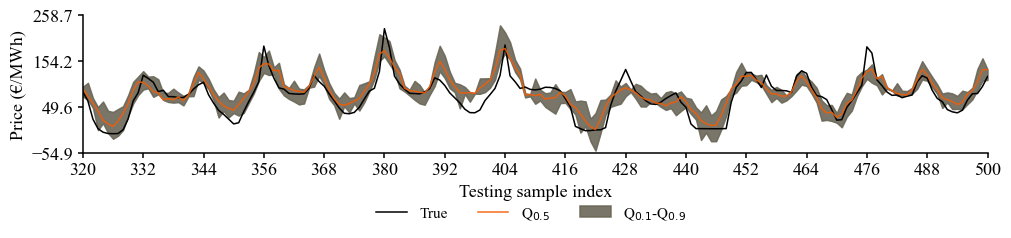

In [ ]:
# Configuration for visualization
window_size = 181  # 181 hours worth of hourly data for sliding window
stop_index = 500  # Limit visualization to first 200 timesteps for demo

# Visualize for each output region
for region in output_regions:
    print(f"\n🎬 Creating dynamic visualization for region: {region}")
    
    # Get concatenated data for this region
    concatenated_forecasts = concatenated_forecasts_dict[region]  # shape: (N, n_quantiles)
    concatenated_y_true = concatenated_y_test_dict[region]       # shape: (N,)
    
    # Extract quantiles: assuming QUANTILES = [10, 50, 90]
    # The forecasts are ordered by quantiles as they appear in QUANTILES list
    q_idx_10 = QUANTILES.index(10)  # First quantile (10%)
    q_idx_50 = QUANTILES.index(50)  # Second quantile (50% - median)
    q_idx_90 = QUANTILES.index(90)  # Third quantile (90%)
    
    y_q10 = concatenated_forecasts[:, q_idx_10]
    y_q50 = concatenated_forecasts[:, q_idx_50]  
    y_q90 = concatenated_forecasts[:, q_idx_90]
    
    y_pred_list = [y_q10, y_q50, y_q90]
    
    print(f"   - Timeline length: {len(concatenated_y_true)} timesteps")
    print(f"   - Window size: {window_size} timesteps")
    print(f"   - Stop index: {stop_index}")
    
    # Create the dynamic sliding window visualization
    live_plot_sliding_window_multi_timestep(
        y_pred_list, concatenated_y_true, window_size, stop_index, region
    )

In [28]:
# Create GIFs from the generated plots
print("🎞️ Creating GIF animations...")

for region in output_regions:
    print(f"Creating GIF for region: {region}")
    gif_conversion(region)

print("✅ All visualizations completed!")

🎞️ Creating GIF animations...
Creating GIF for region: DE_LU
GIF created successfully: Figure/DE_LU_GIF.gif
✅ All visualizations completed!


In [29]:
# Display summary information about the visualization
print("📈 Visualization Summary")
print("=" * 50)

print(f"🎯 Model Configuration:")
print(f"   - Quantiles: {QUANTILES}")
print(f"   - Input regions: {input_regions}")
print(f"   - Output regions: {output_regions}")
print(f"   - Look-back window: {look_back_window} hours")
print(f"   - Prediction horizon: {prediction_horizon} hours (24-hour days)")

print(f"\n📊 Data Summary:")
for region in output_regions:
    forecasts = forecasts_dict[region]
    y_true = y_test_dict[region]
    print(f"   - Region {region}:")
    print(f"     • Test samples: {forecasts.shape[0]} days")
    print(f"     • Hours per day: {forecasts.shape[1]} hours")
    print(f"     • Quantiles: {forecasts.shape[2]} ({QUANTILES})")
    print(f"     • Total timeline: {len(concatenated_y_test_dict[region])} hourly timesteps")

print(f"\n🎬 Visualization Details:")
print(f"   - Sliding window size: {window_size} hours ({window_size//24} days)")
print(f"   - Frames generated: {stop_index - window_size + 1}")
print(f"   - Output files:")
for region in output_regions:
    print(f"     • Individual frames: Figure/{region}/{region}_*.png")
    print(f"     • Animated GIF: Figure/{region}_GIF.gif")

print(f"\n✨ The visualization shows:")
print("   - Black line: True electricity prices")
print("   - Orange line: Median forecast (Q₀.₅)")
print("   - Gray shaded area: Uncertainty band (Q₀.₁ - Q₀.₉)")
print("   - Dynamic sliding window showing forecast evolution over time")

print("\n🎉 Visualization completed successfully!")
print("   You can find the generated GIF in the Figure/ directory.")

📈 Visualization Summary
🎯 Model Configuration:
   - Quantiles: [10, 50, 90]
   - Input regions: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT_1', 'IT_2', 'IT_3', 'IT_4', 'IT_5', 'IT_6', 'IT_7', 'LT', 'LV', 'NL', 'NO_1', 'NO_2', 'NO_3', 'NO_4', 'NO_5', 'PL', 'PT', 'RO', 'SE_1', 'SE_2', 'SE_3', 'SE_4', 'SI', 'SK']
   - Output regions: ['DE_LU']
   - Look-back window: -24 hours
   - Prediction horizon: 23 hours (24-hour days)

📊 Data Summary:
   - Region DE_LU:
     • Test samples: 182 days
     • Hours per day: 24 hours
     • Quantiles: 3 ([10, 50, 90])
     • Total timeline: 4368 hourly timesteps

🎬 Visualization Details:
   - Sliding window size: 181 hours (7 days)
   - Frames generated: 320
   - Output files:
     • Individual frames: Figure/DE_LU/DE_LU_*.png
     • Animated GIF: Figure/DE_LU_GIF.gif

✨ The visualization shows:
   - Black line: True electricity prices
   - Orange line: Median forecast (Q₀.₅)
   - Gray shaded area: Unc